# 01 — EDA: Market Data & Regime Analysis

**Objetivo:** Entender la estructura estadística de los retornos financieros antes de modelar. Un regulador bajo SR 11-7 exige que el modelador demuestre comprensión profunda de los datos antes de validar cualquier modelo. Este notebook es tu evidencia de esa comprensión.

**Prerrequisito:** `python run_all.py` (Stages 1 y 2 ejecutados)

In [ ]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8fafc',
                     'axes.grid':True,'grid.alpha':0.4,'font.size':11})

print("Setup OK")
print(f"Datos disponibles: {[p.name for p in Path('../../data/raw').glob('*.csv')]}")

Setup OK
Datos disponibles: []


## 1. Carga de datos

In [3]:
master   = pd.read_csv('../../data/raw/market_data_master.csv', index_col=0, parse_dates=True)
features = pd.read_csv('../../data/raw/features.csv',           index_col=0, parse_dates=True)

print(f"Master   shape: {master.shape}")
print(f"Features shape: {features.shape}")
print(f"Período: {master.index[0].date()} → {master.index[-1].date()}")
print(f"\nColumnas disponibles:\n")
for col in master.columns: print(f"  {col}")

Master   shape: (6521, 14)
Features shape: (3845, 40)
Período: 2000-01-03 → 2024-12-30

Columnas disponibles:

  equities_EEM
  equities_HYG
  equities_LQD
  equities_SPX
  equities_MERVAL
  equities_VIX
  fx_EURUSD
  fx_GBPUSD
  fx_USDJPY
  bonds_UST_2Y
  bonds_UST_10Y
  macro_FED_FUNDS
  macro_HY_SPREAD
  macro_IG_SPREAD


In [4]:
# Extraer series principales
spx   = master['equities_SPX'].dropna()
vix   = master.get('equities_VIX', pd.Series(dtype=float)).dropna()

# Log-returns: usar features si ya están calculadas, sino calcular
ret_col = 'log_return_SPX'
returns = features[ret_col].dropna() if ret_col in features.columns else np.log(spx/spx.shift(1)).dropna()

print(f"SPX:     {len(spx):5d} obs")
print(f"Returns: {len(returns):5d} obs")
print(f"VIX:     {len(vix):5d} obs")

SPX:      6521 obs
Returns:  3845 obs
VIX:      6521 obs


## 2. Precios, retornos y volatilidad

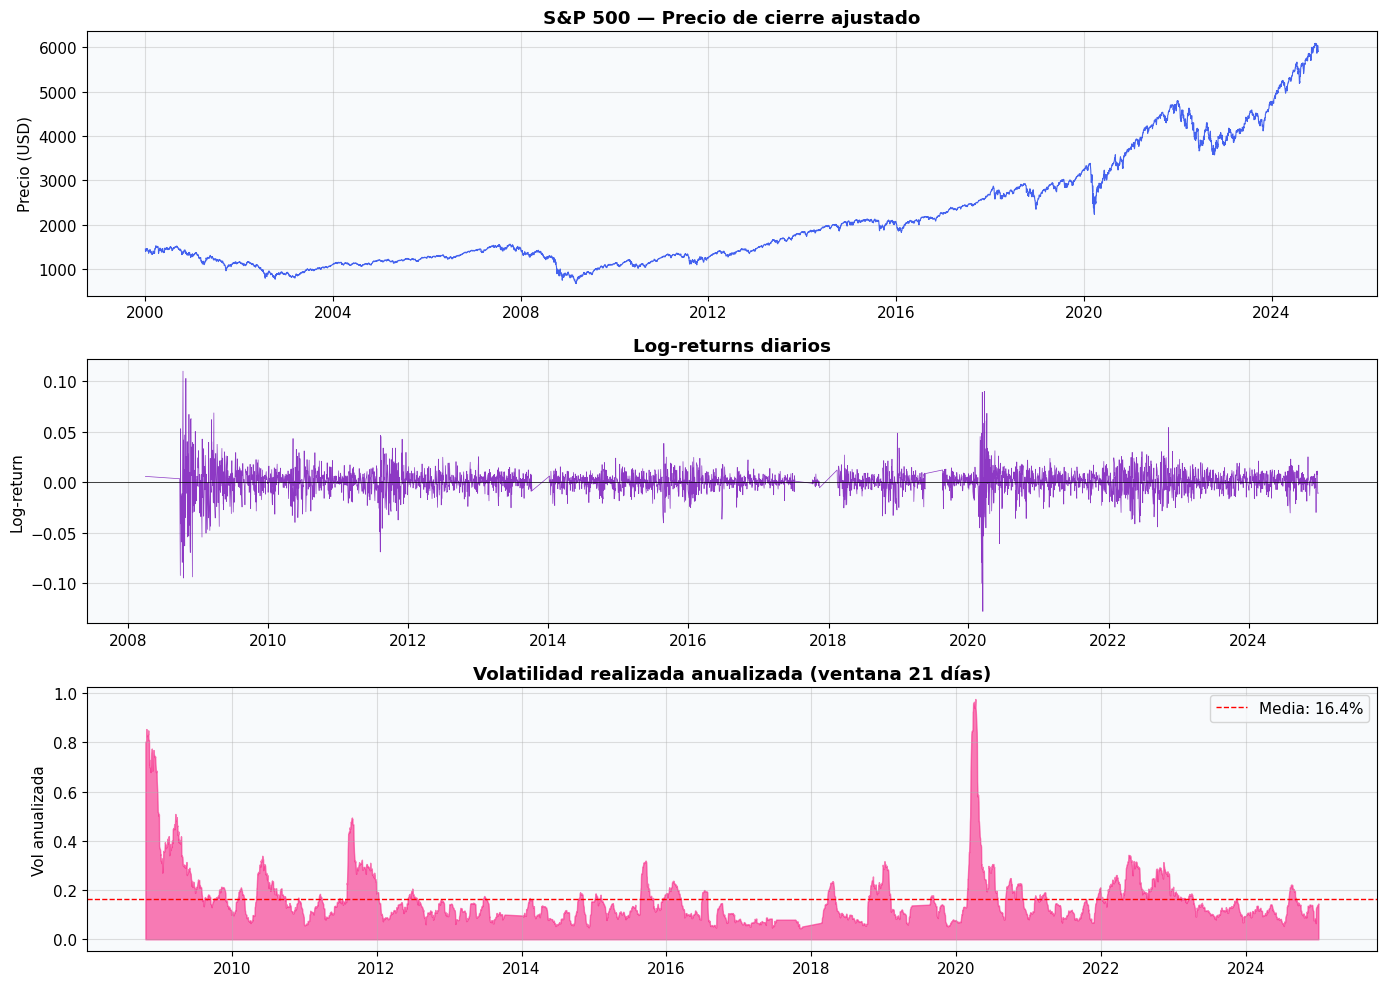

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(spx, color='#4361ee', lw=0.8)
axes[0].set_title('S&P 500 — Precio de cierre ajustado', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')

axes[1].plot(returns, color='#7209b7', lw=0.5, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Log-returns diarios', fontweight='bold')
axes[1].set_ylabel('Log-return')

vol21 = returns.rolling(21).std() * np.sqrt(252)
axes[2].fill_between(vol21.index, vol21, alpha=0.6, color='#f72585')
axes[2].axhline(vol21.mean(), color='red', lw=1, ls='--', label=f'Media: {vol21.mean():.1%}')
axes[2].set_title('Volatilidad realizada anualizada (ventana 21 días)', fontweight='bold')
axes[2].set_ylabel('Vol anualizada')
axes[2].legend()

plt.tight_layout()
plt.savefig('../../reports/figures/01_prices_returns_vol.png', dpi=150, bbox_inches='tight')
plt.show()


* Periodos de alta volatilidad: 

        Crisis Financiera Global (2008-2009): Es el periodo de volatilidad más prolongado, con niveles que superaron el 80% anualizado.

        Pandemia de COVID-19 (Marzo 2020): Presenta el pico más agudo y vertical de toda la serie, rozando el 100% de volatilidad anualizada en un lapso muy corto.

        Crisis de Deuda en la Eurozona (2011): Un repunte notable que llevó la volatilidad cerca del 50%.

        Periodo de Inflación/Guerra en Ucrania (2022): Se observa una volatilidad sostenida por encima de la media (línea roja), aunque sin los picos extremos de 2008 o 2020.

* ¿Hay clustering de volatilidad?
        
        Sí, de manera muy evidente. El fenómeno que observas se conoce técnicamente como Heterocedasticidad Condicional. Si miras el segundo gráfico (Log-returns diarios), verás que los movimientos grandes (tanto positivos como negativos) no están distribuidos al azar, sino que vienen en "rachas".A un día de alta varianza le suelen seguir otros días de alta varianza.A periodos de calma (2013-2017) les siguen largos periodos de baja varianza.Nota: Esto confirma que la varianza no es constante en el tiempo, lo que invalida modelos estadísticos simples que asumen una distribución normal estática.   

* ¿Qué implicaciones tiene esto para el VaR (Value at Risk)? 
        
        El clustering de volatilidad tiene implicaciones críticas para la gestión de riesgos y el cálculo del VaR:

        Fallas del VaR Histórico/Estático: Si calculas el VaR usando una ventana de tiempo muy larga o asumiendo que la volatilidad es constante, subestimarás drásticamente el riesgo durante una crisis (el modelo no "ve" venir el cluster) y lo sobreestimarás en tiempos de calma.

        Necesidad de Modelos Dinámicos: Debido a este agrupamiento, es imperativo usar modelos tipo GARCH o EWMA (Exponentially Weighted Moving Average). Estos modelos dan más peso a los retornos recientes, permitiendo que el límite del VaR se "ajuste" rápidamente cuando la volatilidad empieza a subir.

        Eventos de "Cola Ancha" (Fat Tails): Los clusters suelen venir acompañados de retornos extremos. Para un cálculo preciso del VaR, no basta con mirar la volatilidad; a menudo hay que usar distribuciones como la t-Student para capturar esos picos que se ven en 2008 y 2020, que una distribución normal simplemente ignoraría.

## 3. Distribución de retornos — Normal vs. realidad

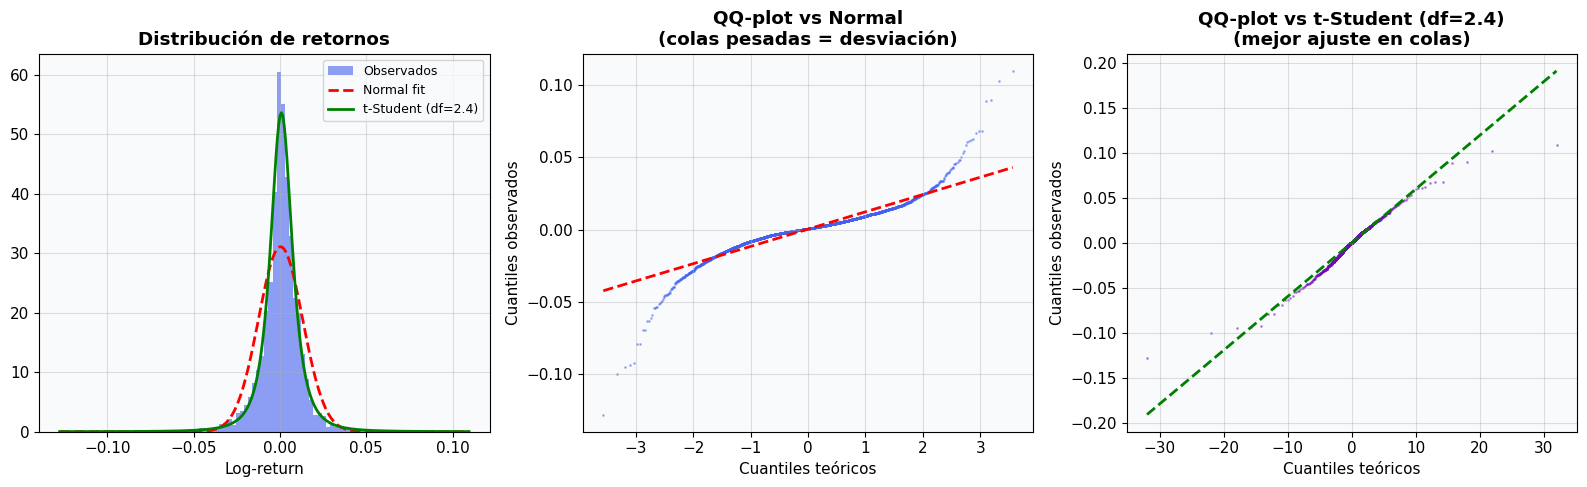

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma + fits
ax = axes[0]
ax.hist(returns, bins=100, density=True, color='#4361ee', alpha=0.6, label='Observados')
x = np.linspace(returns.min(), returns.max(), 300)
mu, sig = returns.mean(), returns.std()
ax.plot(x, stats.norm.pdf(x, mu, sig), 'r--', lw=2, label='Normal fit')
df_t, loc_t, sc_t = stats.t.fit(returns)
ax.plot(x, stats.t.pdf(x, df_t, loc_t, sc_t), 'g-', lw=2, label=f't-Student (df={df_t:.1f})')
ax.set_title('Distribución de retornos', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlabel('Log-return')

# QQ Normal
ax = axes[1]
(osm, osr),(slope,intercept,_) = stats.probplot(returns, dist='norm')
ax.scatter(osm, osr, s=1, color='#4361ee', alpha=0.4)
ax.plot(osm, slope*np.array(osm)+intercept, 'r--', lw=2)
ax.set_title('QQ-plot vs Normal\n(colas pesadas = desviación)', fontweight='bold')
ax.set_xlabel('Cuantiles teóricos'); ax.set_ylabel('Cuantiles observados')

# QQ t-Student
ax = axes[2]
(osm2,osr2),(s2,i2,_) = stats.probplot(returns, dist='t', sparams=(df_t,))
ax.scatter(osm2, osr2, s=1, color='#7209b7', alpha=0.4)
ax.plot(osm2, s2*np.array(osm2)+i2, 'g--', lw=2)
ax.set_title(f'QQ-plot vs t-Student (df={df_t:.1f})\n(mejor ajuste en colas)', fontweight='bold')
ax.set_xlabel('Cuantiles teóricos'); ax.set_ylabel('Cuantiles observados')

plt.tight_layout()
plt.savefig('../../reports/figures/01_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Estadísticas descriptivas clave
jb_stat, jb_p = stats.jarque_bera(returns)
var99  = returns.quantile(0.01)
var975 = returns.quantile(0.025)
es975  = returns[returns <= var975].mean()

print("=" * 55)
print("Estadísticas descriptivas — retornos SPX")
print("=" * 55)
print(f"  N observaciones    : {len(returns):>10,}")
print(f"  Media diaria       : {returns.mean():>10.6f}")
print(f"  Std diaria         : {returns.std():>10.6f}")
print(f"  Vol anualizada     : {returns.std()*np.sqrt(252):>10.2%}")
print(f"  Skewness           : {returns.skew():>10.3f}  (Normal = 0)")
print(f"  Kurtosis exceso    : {returns.kurtosis():>10.3f}  (Normal = 0)")
print(f"  Min (peor día)     : {returns.min():>10.4f}  ({returns.idxmin().date()})")
print(f"  Max (mejor día)    : {returns.max():>10.4f}  ({returns.idxmax().date()})")
print(f"  VaR 99%  histórico : {var99:>10.4f}")
print(f"  VaR 97.5%histórico : {var975:>10.4f}")
print(f"  ES  97.5%histórico : {es975:>10.4f}")
print(f"  df t-Student fit   : {df_t:>10.2f}")
print(f"\nJarque-Bera test:")
print(f"  Estadístico: {jb_stat:.2f}  |  p-value: {jb_p:.2e}")
print(f"  {'✗ RECHAZA normalidad (p < 0.05)' if jb_p<0.05 else '✓ No rechaza normalidad'}")

Estadísticas descriptivas — retornos SPX
  N observaciones    :      3,845
  Media diaria       :   0.000363
  Std diaria         :   0.012829
  Vol anualizada     :     20.37%
  Skewness           :     -0.530  (Normal = 0)
  Kurtosis exceso    :     13.042  (Normal = 0)
  Min (peor día)     :    -0.1277  (2020-03-16)
  Max (mejor día)    :     0.1096  (2008-10-13)
  VaR 99%  histórico :    -0.0372
  VaR 97.5%histórico :    -0.0261
  ES  97.5%histórico :    -0.0417
  df t-Student fit   :       2.36

Jarque-Bera test:
  Estadístico: 27354.25  |  p-value: 0.00e+00
  ✗ RECHAZA normalidad (p < 0.05)


Análisis de Riesgo: SPX
1. Dinámica de Volatilidad
        ¿En qué períodos es más alta?

        Los picos de estrés coinciden con crisis globales: 2008-2009 (Lehman Brothers), 2011 (Eurozona), 2020 (Pandemia) y 2022 (Guerra/Inflación).

        Clustering de Volatilidad

        Existe Heterocedasticidad Condicional: los movimientos fuertes vienen en "rachas". Si hoy hay alta volatilidad, es muy probable que mañana también la haya.

        Implicaciones para el VaR

        Falla del VaR Estático: Ignora el clustering y subestima el riesgo en crisis.

        Modelos Dinámicos: Es necesario usar GARCH o EWMA para ajustar el riesgo rápidamente.

2. Distribución y Estadísticos
        Kurtosis y VaR Normal

        La Kurtosis de 13.04 (leptocúrtica) indica colas pesadas. Los eventos extremos ocurren mucho más de lo que predice una distribución Normal, por lo que el VaR Normal fallará.

        Ajuste t-Student

        El QQ-plot vs t-Student (df=2.36) ajusta mejor porque este modelo sí contempla la probabilidad de eventos extremos ("cisnes negros") que la Normal ignora.

        Subestimación del Riesgo (Ejemplo)

        VaR 99% Normal: ~ -2.95%.

        VaR 99% Histórico: -3.72%.

        Impacto: En una cartera de 100M USD, usar el supuesto Normal implica subestimar la pérdida potencial en $770,000 USD.

        Test Jarque-Bera

        Con un p-value de 0.00, se RECHAZA la normalidad. Los retornos no siguen una campana de Gauss.

## 4. Análisis de regímenes de mercado

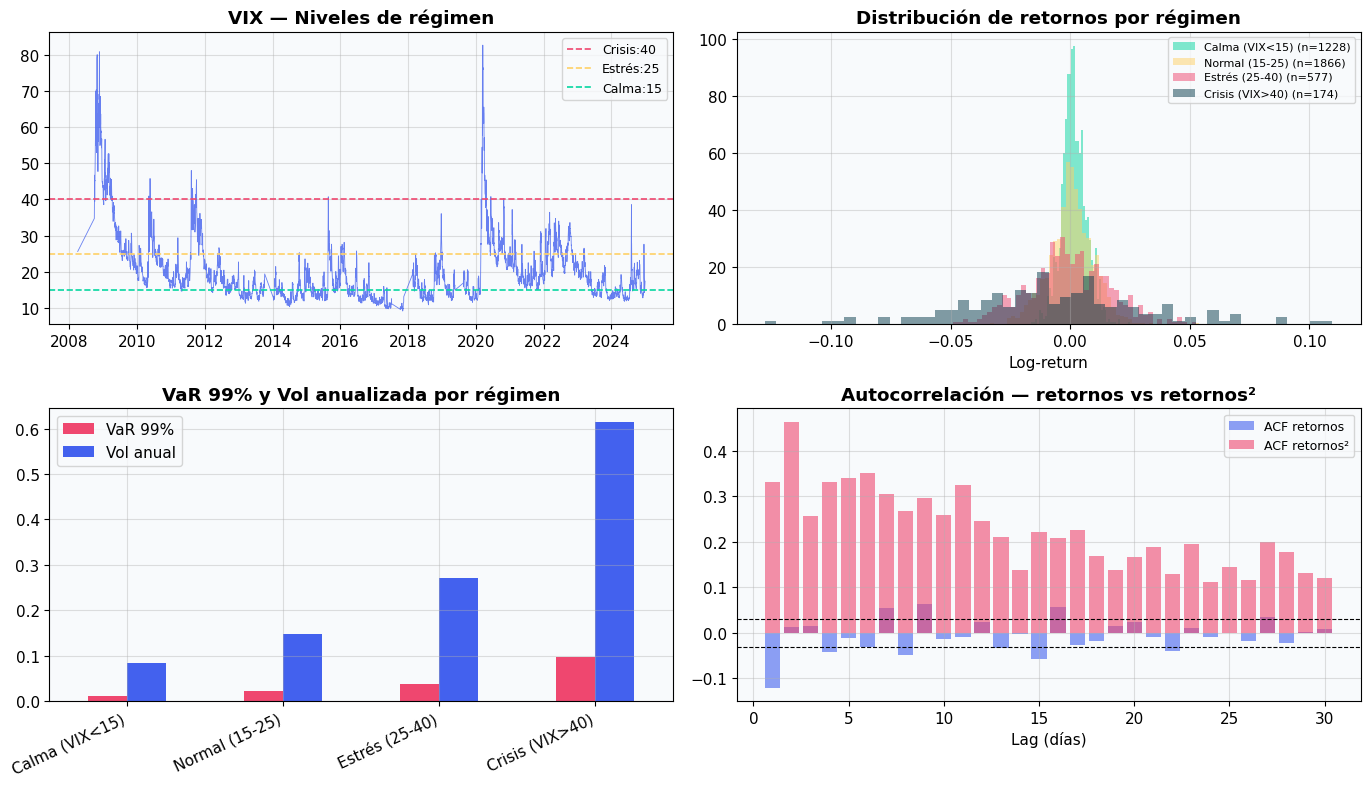


VaR 99% por régimen:
  Calma (VIX<15)      : VaR=0.0112 | Vol=8.29%
  Normal (15-25)      : VaR=0.0228 | Vol=14.80%
  Estrés (25-40)      : VaR=0.0379 | Vol=27.08%
  Crisis (VIX>40)     : VaR=0.0961 | Vol=61.40%


In [9]:
if not vix.empty:
    vix_a = vix.reindex(returns.index).ffill()
    regimes = pd.cut(vix_a, bins=[0,15,25,40,200],
                     labels=['Calma (VIX<15)','Normal (15-25)','Estrés (25-40)','Crisis (VIX>40)'])
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    colors = ['#06d6a0','#ffd166','#ef476f','#073b4c']
    
    # VIX con líneas de régimen
    ax = axes[0,0]
    ax.plot(vix_a, color='#4361ee', lw=0.6, alpha=0.8)
    for threshold, color, label in [(40,'#ef476f','Crisis'),
                                    (25,'#ffd166','Estrés'), (15,'#06d6a0','Calma')]:
        ax.axhline(threshold, color=color, lw=1.2, ls='--', label=f'{label}:{threshold}')
    ax.set_title('VIX — Niveles de régimen', fontweight='bold'); ax.legend(fontsize=9)
    
    # Retornos por régimen
    ax = axes[0,1]
    for label, color in zip(regimes.cat.categories, colors):
        mask = regimes == label
        if mask.sum() > 10:
            ax.hist(returns[mask], bins=50, density=True, alpha=0.5,
                    label=f'{label} (n={mask.sum()})', color=color)
    ax.set_title('Distribución de retornos por régimen', fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlabel('Log-return')
    
    # VaR por régimen
    ax = axes[1,0]
    rv = {}
    for label in regimes.cat.categories:
        mask = regimes == label
        if mask.sum() > 20:
            r = returns[mask]
            rv[str(label)] = {'VaR 99%': abs(r.quantile(0.01)),
                               'Vol anual': r.std()*np.sqrt(252)}
    if rv:
        pd.DataFrame(rv).T.plot(kind='bar', ax=ax, color=['#ef476f','#4361ee'])
        ax.set_title('VaR 99% y Vol anualizada por régimen', fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    
    # ACF retornos vs retornos²
    ax = axes[1,1]
    lags = range(1,31)
    acf_r  = [returns.autocorr(lag=l) for l in lags]
    acf_r2 = [(returns**2).autocorr(lag=l) for l in lags]
    ax.bar(lags, acf_r,  alpha=0.6, color='#4361ee', label='ACF retornos')
    ax.bar(lags, acf_r2, alpha=0.6, color='#ef476f', label='ACF retornos²')
    ci = 1.96/np.sqrt(len(returns))
    ax.axhline(ci, ls='--', color='black', lw=0.8)
    ax.axhline(-ci, ls='--', color='black', lw=0.8)
    ax.set_title('Autocorrelación — retornos vs retornos²', fontweight='bold')
    ax.set_xlabel('Lag (días)'); ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/01_regimes.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Tabla resumen
    print("\nVaR 99% por régimen:")
    for lbl, vals in rv.items():
        print(f"  {lbl:20s}: VaR={vals['VaR 99%']:.4f} | Vol={vals['Vol anual']:.2%}")
else:
    print("VIX no disponible — calculando regímenes por drawdown")
    rm = spx.rolling(252,min_periods=1).max()
    dd = (spx/rm)-1
    print(f"Drawdown máximo: {dd.min():.1%}  |  Días con dd>20%: {(dd<-0.20).sum()}")

1. Dinámica del VaR por Régimen de Volatilidad
        ¿Cómo cambia el VaR entre calma y crisis?

        El cambio es exponencial. Mientras que en régimen de Calma el VaR 99% es de 1.12%, en régimen de Crisis salta a 9.61%. Esto significa que la pérdida potencial es casi 9 veces mayor bajo estrés.

        ¿Es válido un modelo calibrado en calma para una crisis?

        No. Un modelo calibrado en periodos de calma subestimaría masivamente el riesgo. Como muestra el gráfico de Distribución de retornos por régimen en image_9e4b9a.png, las distribuciones de crisis (gris) son mucho más anchas y desplazadas hacia la izquierda, invalidando cualquier supuesto de riesgo estático.

2. Autocorrelación y Modelos GARCH
        ¿Qué muestra el ACF de retornos²?

        El gráfico de Autocorrelación revela un hecho fundamental: mientras que los retornos simples (azul) casi no tienen memoria, los retornos al cuadrado (rosa) muestran una autocorrelación persistente y significativa en casi todos los lags.

        ¿Por qué existe GARCH?

        GARCH existe para explotar esta memoria en la varianza. El ACF de retornos² es la prueba estadística del Clustering de Volatilidad: la magnitud de los shocks de hoy depende de los de ayer. GARCH captura matemáticamente esta dependencia para que el VaR sea dinámico y no una constante ciega.

3. Ventaja del TFT (Temporal Fusion Transformer) vs GARCH
        El Temporal Fusion Transformer (TFT) ofrece ventajas críticas sobre los modelos GARCH tradicionales:

        Multimodalidad: GARCH solo mira retornos pasados. El TFT puede integrar variables externas como el VIX, volúmenes y datos macro de manera nativa.

        Atención Temporal: Gracias a sus mecanismos de atención, el TFT puede identificar qué eventos pasados (como una crisis hace 10 días) son más relevantes hoy, mientras que GARCH tiene un decaimiento fijo.

        Adaptación de Régimen: El TFT es capaz de detectar cambios de régimen (de Calma a Crisis) más rápido que los modelos econométricos clásicos, capturando dependencias no lineales complejas que GARCH ignora.

        Jarque-Bera Ref: Como vimos anteriormente, la normalidad se rechaza. Estos regímenes explican por qué: el mercado es un sistema que cambia de estado, no una distribución estática.

## 5. Correlaciones y contagio

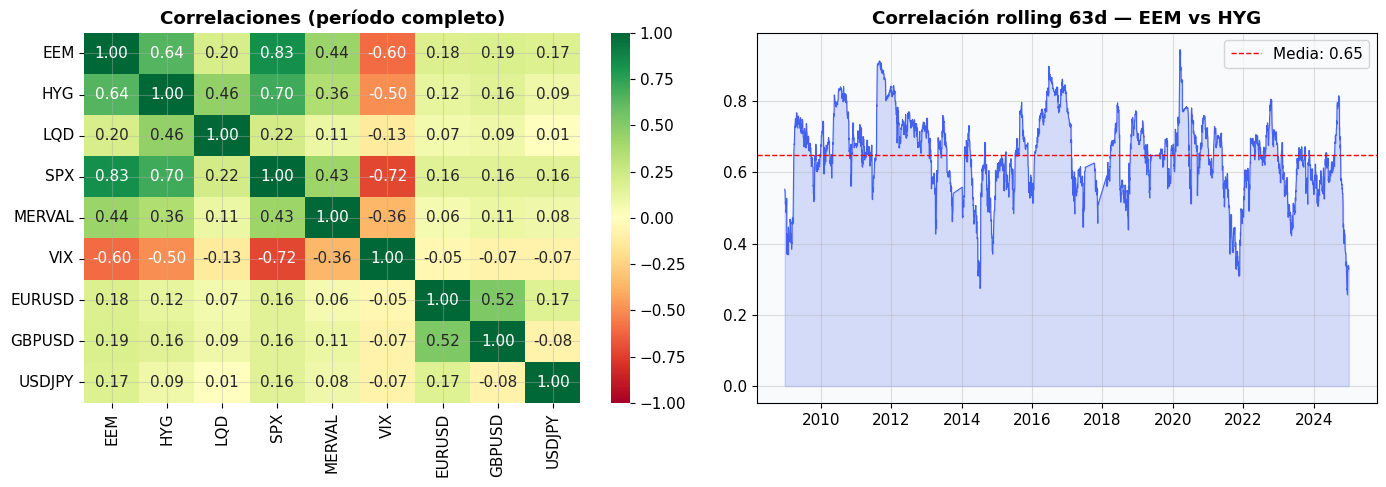


Correlación media EEM/HYG: 0.649
Correlación mínima observada: 0.256  (2024-12-16)
Correlación máxima observada: 0.944  (2020-03-16)


In [11]:
ret_cols = [c for c in features.columns if c.startswith('log_return_')]
if len(ret_cols) >= 2:
    key_rets = features[ret_cols].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap correlaciones
    ax = axes[0]
    corr = key_rets.corr()
    labels = [c.replace('log_return_','') for c in corr.columns]
    corr.columns = labels; corr.index = labels
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlaciones (período completo)', fontweight='bold')
    
    # Correlación rolling
    ax = axes[1]
    c1, c2 = ret_cols[0], ret_cols[1]
    rc = features[c1].rolling(63).corr(features[c2])
    ax.plot(rc, color='#4361ee', lw=0.8)
    ax.fill_between(rc.index, rc, alpha=0.2, color='#4361ee')
    ax.axhline(rc.mean(), color='red', ls='--', lw=1, label=f'Media: {rc.mean():.2f}')
    l1 = c1.replace('log_return_',''); l2 = c2.replace('log_return_','')
    ax.set_title(f'Correlación rolling 63d — {l1} vs {l2}', fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/01_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nCorrelación media {l1}/{l2}: {rc.mean():.3f}")
    print(f"Correlación mínima observada: {rc.min():.3f}  ({rc.idxmin().date()})")
    print(f"Correlación máxima observada: {rc.max():.3f}  ({rc.idxmax().date()})")
else:
    print("Solo 1 serie de retornos disponible — análisis univariado")

1. El Fenómeno de "Correlation Breakdown" en Crisis
        ¿Qué pasa con las correlaciones durante una crisis?

        Durante eventos de pánico extremo, las correlaciones tienden a converger hacia 1. Como se observa en la imagen para el par EEM/HYG, la correlación máxima de 0.944 ocurrió precisamente el 16 de marzo de 2020 (pico del crash por COVID-19).

        Este fenómeno, conocido como Correlation Breakdown, implica que la diversificación —el único "almuerzo gratis" en finanzas— desaparece justo cuando más se necesita, ya que todos los activos de riesgo caen simultáneamente.

2. Riesgos de la Correlación Constante en el VaR
        ¿Por qué las correlaciones constantes subestiman el riesgo?

        Si un modelo de VaR de portafolio utiliza la correlación media (0.649 en este caso), asumirá un beneficio de diversificación que no existirá en un escenario de estrés. Al ignorar que la correlación puede saltar a niveles cercanos a 0.95, el modelo:

        Subestima la volatilidad conjunta: Al creer que los activos compensarán sus movimientos.

        Genera un VaR demasiado optimista: Resultando en requerimientos de capital insuficientes para cubrir pérdidas reales en crisis.

3. Ventaja del TFT con Correlaciones Rolling
        ¿Cómo mitiga esto el Temporal Fusion Transformer (TFT)?

        A diferencia de los modelos tradicionales que ven la correlación como un parámetro estático, el TFT puede utilizar la correlación rolling (visto en el gráfico derecho en la imagen) como una feature dinámica:

        Identificación de Regímenes: El TFT puede aprender a detectar cuándo el mercado entra en un régimen de "correlación alta" y ajustar sus predicciones de riesgo preventivamente.

        Interacción de Variables: Al procesar series de tiempo multivariantes, el modelo captura la sensibilidad de estas correlaciones ante picos de volatilidad (VIX), permitiendo un VaR de portafolio mucho más robusto y adaptativo que los métodos de varianza-covarianza clásicos.

## 6. Resumen ejecutivo — hallazgos para el modelo

In [12]:
print("=" * 60)
print("RESUMEN EDA — Inputs para decisiones de modelado")
print("=" * 60)
jb_stat, jb_p = stats.jarque_bera(returns)
var99  = float(returns.quantile(0.01))
var975 = float(returns.quantile(0.025))
es975  = float(returns[returns <= returns.quantile(0.025)].mean())
kurt   = float(returns.kurtosis())
skew   = float(returns.skew())
vol_a  = float(returns.std() * np.sqrt(252))
print(f"  Kurtosis exceso  : {kurt:.2f} → colas {('MUY ' if kurt>5 else '')}pesadas")
print(f"  Skewness         : {skew:.3f} → distribución {'negativa' if skew<0 else 'positiva'}")
print(f"  Jarque-Bera p    : {jb_p:.2e} → {'rechaza' if jb_p<0.05 else 'no rechaza'} normalidad")
print(f"  Vol anualizada   : {vol_a:.2%}")
print(f"  VaR 99%  (hist.) : {var99:.4f}")
print(f"  VaR 97.5%(hist.) : {var975:.4f}")
print(f"  ES  97.5%(hist.) : {es975:.4f}")
print()
print("Decisiones de modelado derivadas:")
print("  ✓ Usar t-Student (no Normal) → GARCH + MC con dist=t")
print("  ✓ Pinball loss en TFT/LSTM para cuantiles sin supuestos dist.")
print("  ✓ ES 97.5% como métrica principal (Basel III FRTB)")
print("  ✓ Features de régimen (VIX, drawdown) para el TFT")
print("  ✓ Correlaciones rolling para capturar correlation breakdown")

RESUMEN EDA — Inputs para decisiones de modelado
  Kurtosis exceso  : 13.04 → colas MUY pesadas
  Skewness         : -0.530 → distribución negativa
  Jarque-Bera p    : 0.00e+00 → rechaza normalidad
  Vol anualizada   : 20.37%
  VaR 99%  (hist.) : -0.0372
  VaR 97.5%(hist.) : -0.0261
  ES  97.5%(hist.) : -0.0417

Decisiones de modelado derivadas:
  ✓ Usar t-Student (no Normal) → GARCH + MC con dist=t
  ✓ Pinball loss en TFT/LSTM para cuantiles sin supuestos dist.
  ✓ ES 97.5% como métrica principal (Basel III FRTB)
  ✓ Features de régimen (VIX, drawdown) para el TFT
  ✓ Correlaciones rolling para capturar correlation breakdown
